<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/Emotion_Detection_using_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers datasets accelerate peft

In [ ]:
# NumPy: numerical operations
import numpy as np

# Pandas: working with tables/data
import pandas as pd

# PyTorch: deep learning framework used by Transformers
import torch

# Matplotlib: plotting
import matplotlib.pyplot as plt

# Seaborn: better-looking statistical plots
import seaborn as sns

# Load dataset from Hugging Face
from datasets import load_dataset

# Hugging Face Transformer classes
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [ ]:
# Load the dair-ai/emotion dataset from Hugging Face.

dataset = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print(dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0}


In [ ]:
# Print the number of examples in each dataset split.

print("Training examples:", len(dataset["train"]))
print("Validation examples:", len(dataset["validation"]))
print("Test examples:", len(dataset["test"]))

Training examples: 16000
Validation examples: 2000
Test examples: 2000


In [ ]:
# Get the emotion names from the dataset.

label_names = dataset["train"].features["label"].names

print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [ ]:
# Create a mapping from numeric ID to emotion name.

id2label = {
    i: label
    for i, label in enumerate(label_names)
}

print(id2label)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
# Create a mapping from  emotion name to numeric ID

# Create the reverse mapping:
# emotion name → numeric ID

label2id = {
    label: i
    for i, label in enumerate(label_names)
}

print(label2id)

{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


 Visualize class distribution

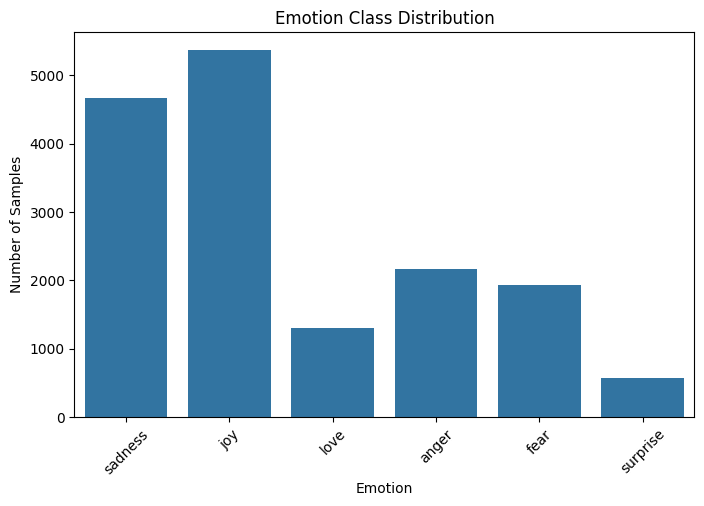

In [ ]:
# Get labels from the training dataset.

train_labels = dataset["train"]["label"]

# Count how many examples belong to each class.

label_counts = pd.Series(train_labels).value_counts().sort_index()

# Create the plot.

plt.figure(figsize=(8, 5))

sns.barplot(
    x=[id2label[i] for i in label_counts.index],
    y=label_counts.values
)

plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.title("Emotion Class Distribution")

plt.xticks(rotation=45)

plt.show()

In [ ]:
#Choose the Transformer
# We will use pretrained BERT.

model_checkpoint = "bert-base-uncased"

# Load the BERT tokenizer.

tokenizer = AutoTokenizer.from_pretrained(
    model_checkpoint
)

def tokenize_function(examples):

    # Convert text into BERT tokens.

    return tokenizer(
        examples["text"],

        # Make all sequences the same length.
        padding="max_length",

        # Cut sequences longer than max_length.
        truncation=True,

        # Maximum sequence length.
        max_length=128
    )


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Apply our tokenizer to train, validation and test datasets.

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [ ]:
#Load BERT classification model
model = AutoModelForSequenceClassification.from_pretrained(

    # Pretrained BERT
    model_checkpoint,

    # Six emotion classes
    num_labels=6,

    # Numeric ID → emotion name
    id2label=id2label,

    # Emotion name → numeric ID
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):

    # Get model predictions and actual labels.
    logits, labels = eval_pred

    # Select the class with the highest score.
    predictions = np.argmax(logits, axis=-1)

    # Calculate precision, recall and F1.
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    # Calculate accuracy.
    accuracy = accuracy_score(
        labels,
        predictions
    )

    # Return all metrics.
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [ ]:


training_args = TrainingArguments(
    output_dir="./emotion_model",

    num_train_epochs=1,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    report_to="none"
)



In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

In [ ]:
# 4. Fine-tune BERT
trainer.train()



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.160812,0.159487,0.938500,0.939150,0.938500,0.938698


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1000, training_loss=0.1773937301635742, metrics={'train_runtime': 385.8369, 'train_samples_per_second': 41.468, 'train_steps_per_second': 2.592, 'total_flos': 1052482019328000.0, 'train_loss': 0.1773937301635742, 'epoch': 1.0})

In [ ]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.160812,0.159487,1,0.938500,0.939150,0.938500,0.938698


{'eval_loss': 0.15948733687400818, 'eval_accuracy': 0.9385, 'eval_precision': 0.9391500184659763, 'eval_recall': 0.9385, 'eval_f1': 0.9386975479250491}


In [ ]:
test_results = trainer.evaluate(
    tokenized_dataset["test"]
)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.160812,0.176060,1,0.930500,0.930822,0.930500,0.930504


{'eval_loss': 0.1760595589876175, 'eval_accuracy': 0.9305, 'eval_precision': 0.9308220319652629, 'eval_recall': 0.9305, 'eval_f1': 0.9305036235557664}


In [ ]:
predictions = trainer.predict(
    tokenized_dataset["test"]
)

In [ ]:
true_labels = predictions.label_ids

In [ ]:
predicted_labels = np.argmax(
    predictions.predictions,
    axis=-1
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.97      0.96      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.84      0.84      0.84       159
       anger       0.93      0.90      0.92       275
        fear       0.87      0.93      0.90       224
    surprise       0.79      0.76      0.78        66

    accuracy                           0.93      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.93      0.93      0.93      2000



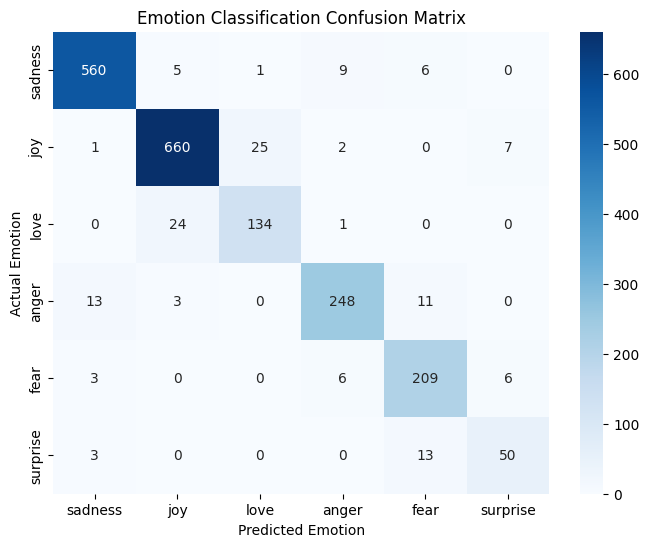

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Emotion Classification Confusion Matrix")

plt.show()

In [ ]:
def predict_emotion(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

    predicted_id = torch.argmax(
        outputs.logits,
        dim=-1
    ).item()

    emotion = id2label[predicted_id]

    return emotion


In [ ]:
text = "I am very happy today!"

prediction = predict_emotion(text)

print("Text:", text)
print("Emotion:", prediction)

Text: I am very happy today!
Emotion: joy


In [ ]:
def test_dataset_sentence(index):

    # Get sentence and actual label
    sample = dataset["test"][index]

    text = sample["text"]
    actual_id = sample["label"]

    # Convert actual ID to emotion
    actual_emotion = id2label[actual_id]

    # Tokenize sentence
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move input to same device as model
    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    # Prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities
    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    # Get predicted class
    predicted_id = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    # Convert predicted ID to emotion
    predicted_emotion = id2label[predicted_id]

    # Confidence
    confidence = probabilities[0][predicted_id].item()

    # Print results
    print("Sentence:")
    print(text)

    print("\nActual emotion:")
    print(actual_emotion)

    print("\nPredicted emotion:")
    print(predicted_emotion)

    print(f"\nConfidence: {confidence * 100:.2f}%")

    if actual_id == predicted_id:
        print("\nResult: CORRECT ✅")
    else:
        print("\nResult: WRONG ❌")


In [ ]:
for i in range(10):
    test_dataset_sentence(i)
    print("=" * 70)

Sentence:
im feeling rather rotten so im not very ambitious right now

Actual emotion:
sadness

Predicted emotion:
sadness

Confidence: 99.74%

Result: CORRECT ✅
Sentence:
im updating my blog because i feel shitty

Actual emotion:
sadness

Predicted emotion:
sadness

Confidence: 99.83%

Result: CORRECT ✅
Sentence:
i never make her separate from me because i don t ever want her to feel like i m ashamed with her

Actual emotion:
sadness

Predicted emotion:
sadness

Confidence: 99.84%

Result: CORRECT ✅
Sentence:
i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived

Actual emotion:
joy

Predicted emotion:
joy

Confidence: 99.72%

Result: CORRECT ✅
Sentence:
i was feeling a little vain when i did this one

Actual emotion:
sadness

Predicted emotion:
sadness

Confidence: 99.83%

Result: CORRECT ✅
Sentence:
i cant walk into a shop anywhere where i do not feel uncomfortable

Actual emotion:
fear

Predicted emotion:
fear

Confidence: